## Task #3 - Heart Disease Prediction 

`Objective`:  

Build a model to predict whether a person is at risk of heart disease based on their health data.  

`Dataset`:
  
Heart Disease UCI Dataset (available on Kaggle)  

-----------------

## Problem Statement

Heart disease is one of the leading causes of death worldwide. Early identification of individuals at risk can help in timely medical intervention. 

This project aims to analyze patient health data and build a machine learning model to predict the likelihood of heart disease.

## Goal

To preprocess and analyze the Heart Disease UCI dataset, perform exploratory data analysis (EDA), 

and develop a classification model that can accurately predict whether a person is at risk of heart disease based on their medical attributes.

-----------------

## Importing Libraries and Dataset

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   

In [76]:
df = pd.read_csv("heart_disease_uci.csv")

In [77]:
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


## Exploring the Dataset

In [78]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [80]:
df.shape

(920, 16)

In [81]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [82]:
df


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [83]:
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [84]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
915    False
916    False
917    False
918    False
919    False
Length: 920, dtype: bool

## Cleaning & Preprocessing 

### Filling Null Values:

### 1- trestbps

In [11]:
df["trestbps"]

0      145.0
1      160.0
2      120.0
3      130.0
4      130.0
       ...  
915    127.0
916      NaN
917    122.0
918      NaN
919    120.0
Name: trestbps, Length: 920, dtype: float64

In [85]:
df["trestbps"].fillna(df["trestbps"].mean(),inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_20408\78475680.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["trestbps"].fillna(df["trestbps"].mean(),inplace=True)


In [86]:
df["trestbps"]

0      145.000000
1      160.000000
2      120.000000
3      130.000000
4      130.000000
          ...    
915    127.000000
916    132.132404
917    122.000000
918    132.132404
919    120.000000
Name: trestbps, Length: 920, dtype: float64

### 2- chol

In [87]:
df["chol"]

0      233.0
1      286.0
2      229.0
3      250.0
4      204.0
       ...  
915    333.0
916    139.0
917    223.0
918    385.0
919    254.0
Name: chol, Length: 920, dtype: float64

In [88]:
df["chol"].fillna(df["chol"].mean(),inplace=True)

In [89]:
df["chol"].isnull().sum()

np.int64(0)

### 3- fbs

In [90]:
df["fbs"]

0       True
1      False
2      False
3      False
4      False
       ...  
915     True
916    False
917     True
918     True
919    False
Name: fbs, Length: 920, dtype: object

In [91]:
df["fbs"].isnull().sum()

np.int64(90)

In [92]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="most_frequent")

df[["fbs"]] = imputer.fit_transform(df[["fbs"]])

In [93]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(df)


      id  age     sex        dataset               cp    trestbps        chol  \
0      1   63    Male      Cleveland   typical angina  145.000000  233.000000   
1      2   67    Male      Cleveland     asymptomatic  160.000000  286.000000   
2      3   67    Male      Cleveland     asymptomatic  120.000000  229.000000   
3      4   37    Male      Cleveland      non-anginal  130.000000  250.000000   
4      5   41  Female      Cleveland  atypical angina  130.000000  204.000000   
5      6   56    Male      Cleveland  atypical angina  120.000000  236.000000   
6      7   62  Female      Cleveland     asymptomatic  140.000000  268.000000   
7      8   57  Female      Cleveland     asymptomatic  120.000000  354.000000   
8      9   63    Male      Cleveland     asymptomatic  130.000000  254.000000   
9     10   53    Male      Cleveland     asymptomatic  140.000000  203.000000   
10    11   57    Male      Cleveland     asymptomatic  140.000000  192.000000   
11    12   56  Female      C

### 4- restecg 

In [94]:
df[["restecg"]] = imputer.fit_transform(df[["restecg"]])

In [95]:
df["restecg"].isnull().sum()

np.int64(0)

### 5- thalch

In [96]:
df["thalch"].fillna(df["thalch"].mean(),inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_20408\2594227417.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["thalch"].fillna(df["thalch"].mean(),inplace=True)


In [97]:
df["thalch"].isnull().sum()

np.int64(0)

### 6- exang       

In [98]:
df[["exang"]] = imputer.fit_transform(df[["exang"]])

In [99]:
df["exang"].isnull().sum()

np.int64(0)

### 7- oldpeak

In [100]:
df["oldpeak"].fillna(df["oldpeak"].mean(),inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_20408\2248749968.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["oldpeak"].fillna(df["oldpeak"].mean(),inplace=True)


In [101]:
df[["fbs"]] = imputer.fit_transform(df[["fbs"]])

### 8- slope

In [102]:
df[["slope"]] = imputer.fit_transform(df[["slope"]])

In [103]:
df["slope"].isnull().sum()

np.int64(0)

### 9- ca

In [104]:
df["ca"].fillna(df["ca"].mean(),inplace=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_20408\2359149172.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["ca"].fillna(df["ca"].mean(),inplace=True)


In [105]:
df["ca"].isnull().sum()

np.int64(0)

### 10- thal

In [106]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):  # more options can be specified also
    print(df["thal"])


0           fixed defect
1                 normal
2      reversable defect
3                 normal
4                 normal
5                 normal
6                 normal
7                 normal
8      reversable defect
9      reversable defect
10          fixed defect
11                normal
12          fixed defect
13     reversable defect
14     reversable defect
15                normal
16     reversable defect
17                normal
18                normal
19                normal
20                normal
21                normal
22                normal
23     reversable defect
24     reversable defect
25                normal
26                normal
27                normal
28                normal
29     reversable defect
30                normal
31     reversable defect
32                normal
33     reversable defect
34                normal
35                normal
36     reversable defect
37          fixed defect
38     reversable defect
39                normal


In [107]:
df['thal'] = df['thal'].fillna('Unknown')

In [108]:
df["thal"].isnull().sum()

np.int64(0)

In [109]:
df.isnull().sum()

id          0
age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64

In [120]:
df.head(20)

,id,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,...,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,1,1.007386,0.698041,0.311021,0.495698,1.349421,-1.249371,0,True,False,...,True,True,False,False,False,False,False,True,False,False
1,2,1.432034,1.511761,0.797713,-1.175955,0.589832,4.292099,2,True,False,...,False,False,False,False,True,True,False,False,True,False
2,3,1.432034,-0.658158,0.274289,-0.340128,1.634267,2.444942,1,True,False,...,False,False,False,False,True,True,False,False,False,True
3,4,-1.752828,-0.115679,0.467130,1.968345,2.488805,-1.249371,0,True,False,...,False,False,True,False,False,False,False,False,True,False
4,5,-1.328180,-0.115679,0.044717,1.371326,0.494884,-1.249371,0,False,False,...,False,False,False,False,False,False,True,False,True,False
5,6,0.264251,-0.658158,0.338569,1.610134,-0.074808,-1.249371,0,True,False,...,False,False,True,False,False,False,True,False,True,False
6,7,0.901224,0.426801,0.632421,0.893711,2.583754,2.444942,3,False,False,...,False,False,False,False,False,False,False,False,True,False
7,8,0.370413,-0.658158,1.422148,1.013115,-0.264705,-1.249371,0,False,False,...,False,False,True,False,True,False,True,False,True,False
8,9,1.007386,-0.115679,0.503861,0.376295,0.494884,0.597785,2,True,False,...,False,False,False,False,False,True,False,False,False,True
9,10,-0.054235,0.426801,0.035535,0.694705,2.109010,-1.249371,1,True,False,...,False,True,False,False,True,False,False,False,False,True


In [114]:
col_to_scale = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[col_to_scale] = scaler.fit_transform(df[col_to_scale])

In [127]:
df['ca'] = scaler.fit_transform(df[['ca']])

In [111]:
df = pd.get_dummies(df, drop_first=True)

## Dataset after Preprocessing

In [128]:
df

,id,age,trestbps,chol,thalch,oldpeak,ca,num,sex_Male,dataset_Hungary,...,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_fixed defect,thal_normal,thal_reversable defect
0,1,1.007386,0.698041,0.311021,0.495698,1.349421,-1.249371e+00,0,True,False,...,True,True,False,False,False,False,False,True,False,False
1,2,1.432034,1.511761,0.797713,-1.175955,0.589832,4.292099e+00,2,True,False,...,False,False,False,False,True,True,False,False,True,False
2,3,1.432034,-0.658158,0.274289,-0.340128,1.634267,2.444942e+00,1,True,False,...,False,False,False,False,True,True,False,False,False,True
3,4,-1.752828,-0.115679,0.467130,1.968345,2.488805,-1.249371e+00,0,True,False,...,False,False,True,False,False,False,False,False,True,False
4,5,-1.328180,-0.115679,0.044717,1.371326,0.494884,-1.249371e+00,0,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,0.051927,-0.278423,1.229308,0.654903,-0.834397,-5.640224e-17,1,False,False,...,False,True,False,True,False,True,False,False,False,False
916,917,0.901224,0.000000,-0.552169,0.000000,0.000000,-5.640224e-17,0,True,False,...,True,False,False,True,False,True,False,False,False,False
917,918,0.158089,-0.549662,0.219192,-1.494365,-0.834397,-5.640224e-17,2,True,False,...,False,True,False,True,False,True,False,True,False,False
918,919,0.476575,0.000000,1.706817,0.000000,0.000000,-5.640224e-17,0,True,False,...,False,True,False,False,False,True,False,False,False,False


# Visual Representation of the Dataset

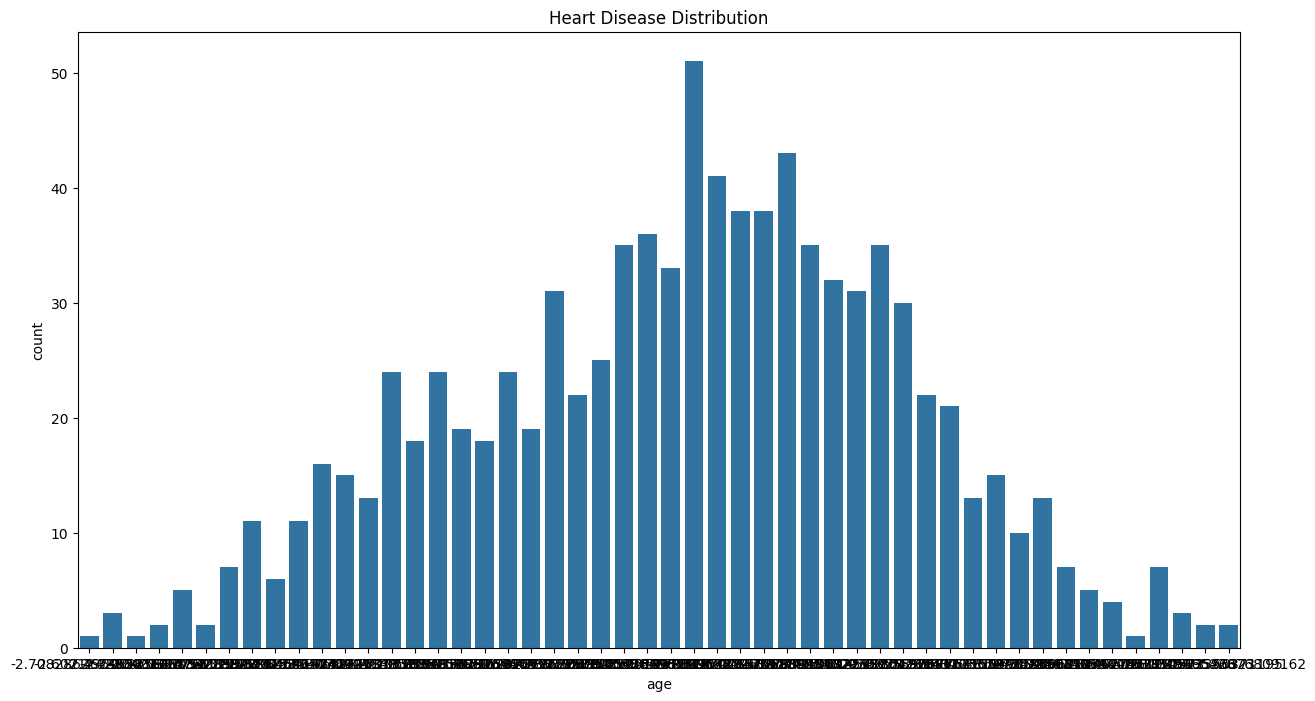

In [121]:
plt.figure(figsize=(15, 8))
sns.countplot(x='age', data=df)
plt.title("Heart Disease Distribution")
plt.show()

                                id       age  trestbps      chol    thalch  \
id                        1.000000  0.239301  0.049369 -0.372984 -0.436795   
age                       0.239301  1.000000  0.235253 -0.084499 -0.353471   
trestbps                  0.049369  0.235253  1.000000  0.088290 -0.104616   
chol                     -0.372984 -0.084499  0.088290  1.000000  0.226325   
thalch                   -0.436795 -0.353471 -0.104616  0.226325  1.000000   
oldpeak                   0.046473  0.248082  0.160268  0.045498 -0.149630   
ca                        0.016474  0.204139  0.051940  0.017544 -0.140644   
num                       0.273552  0.339596  0.116225 -0.228238 -0.351055   
sex_Male                  0.280053  0.056889  0.001073 -0.193782 -0.177135   
dataset_Hungary          -0.024453 -0.407613  0.017003  0.301717  0.038692   
dataset_Switzerland       0.293621  0.075329 -0.040374 -0.718355 -0.247957   
dataset_VA Long Beach     0.714421  0.326713  0.033585 -0.095203

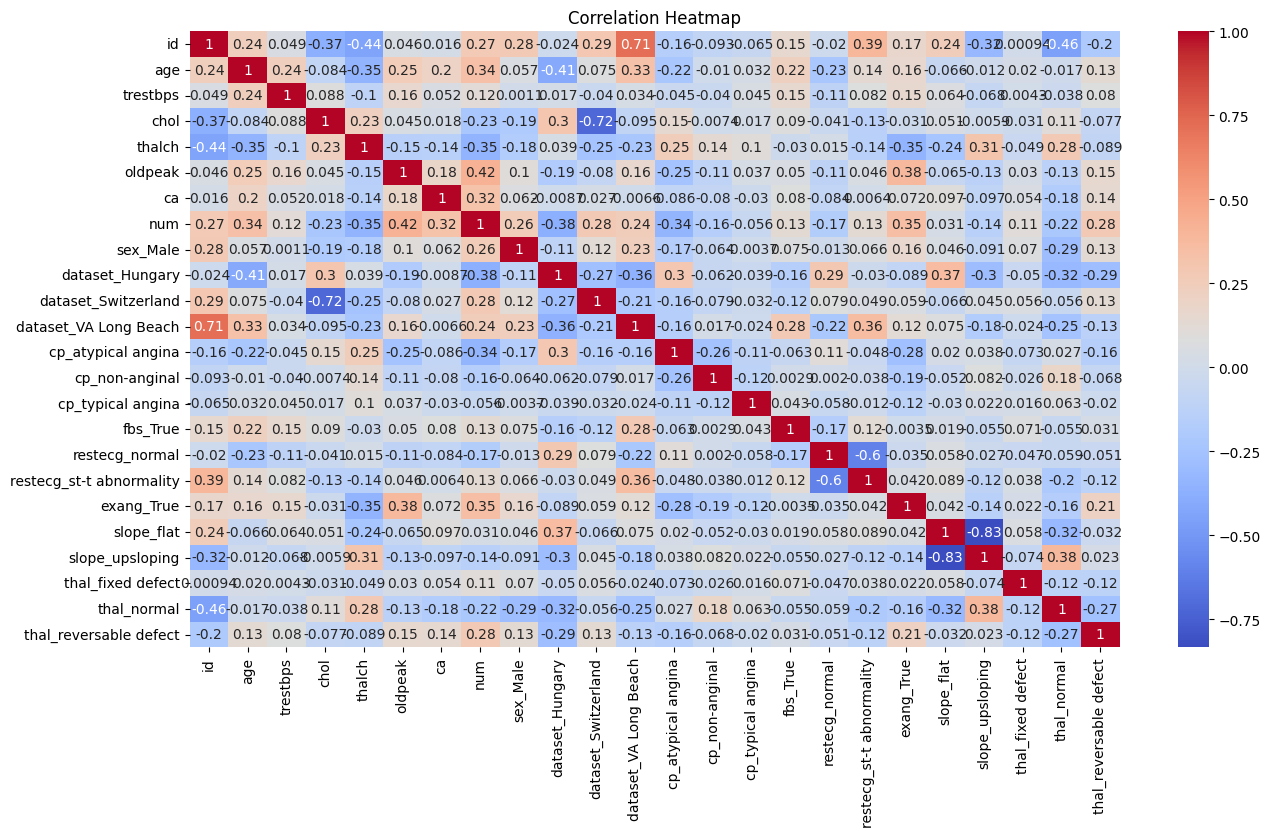

In [122]:
plt.figure(figsize=(15,8))


co_mtx = df.corr(numeric_only=True)

sns.heatmap(
    co_mtx,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
print(co_mtx)
plt.show()

# Training Model and Doing Predictions

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [133]:
X = df.drop(["id", "num"], axis=1)
y = df["num"]

In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [135]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [136]:
y_pred = model.predict(X_test)

In [138]:
accuracy = accuracy_score(y_test, y_pred)

print(f"accuracy_score: {accuracy}")

accuracy_score: 0.5652173913043478


In [139]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[67  7  0  1  0]
 [20 29  0  5  0]
 [ 4 12  3  6  0]
 [ 6 11  3  5  1]
 [ 0  2  1  1  0]]


## Plotting Confusion Matrix

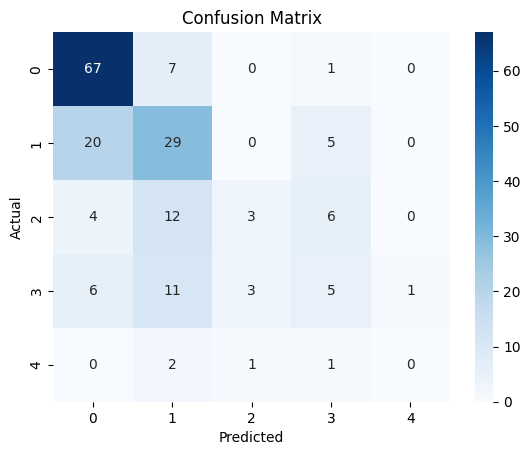

In [141]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [152]:
print(y_test.unique())

[0 1 3 2 4]


In [153]:
y_test_binary = (y_test > 0).astype(int) 

In [155]:
print(y_test_binary)

319    0
377    0
538    1
296    1
531    1
      ..
382    0
97     1
906    1
467    0
732    1
Name: num, Length: 184, dtype: int64


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test_binary, y_proba)

auc = roc_auc_score(y_test_binary, y_proba)

## AUC Score

In [157]:
print(f"AUC Score: {auc}")

AUC Score: 0.8212844036697249


## Plotting ROC Curve

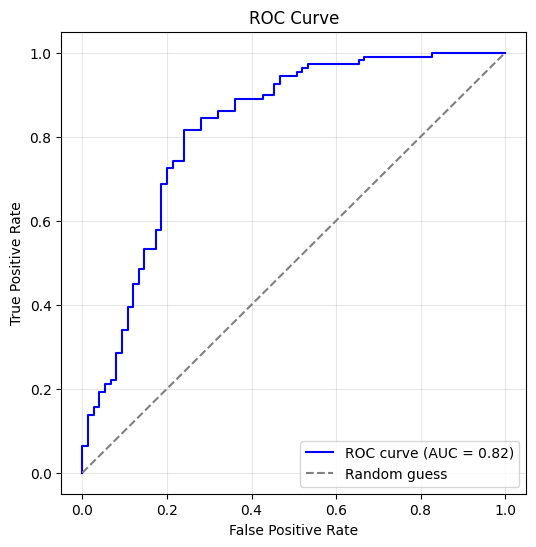

In [158]:
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

In [160]:
feature_names = X.columns
print(feature_names)

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'sex_Male',
       'dataset_Hungary', 'dataset_Switzerland', 'dataset_VA Long Beach',
       'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True',
       'restecg_normal', 'restecg_st-t abnormality', 'exang_True',
       'slope_flat', 'slope_upsloping', 'thal_fixed defect', 'thal_normal',
       'thal_reversable defect'],
      dtype='object')


In [161]:
coefficients = model.coef_[0]
print(coefficients) 

[-0.08399087 -0.06713775 -0.09368962  0.24154902 -0.7882512  -0.56553798
 -1.0346238   1.78169205 -2.13303734 -0.1582999   1.44540426  0.83874323
  0.934893   -0.18463291  0.18242892 -0.25600265 -0.80392042 -0.6130125
 -0.06646356 -0.50212445  0.30433649 -0.53067174]


# Plottin Feature Importance

                     Feature  Coefficient
8        dataset_Switzerland    -2.133037
7            dataset_Hungary     1.781692
10        cp_atypical angina     1.445404
6                   sex_Male    -1.034624
12         cp_typical angina     0.934893
11            cp_non-anginal     0.838743
16                exang_True    -0.803920
4                    oldpeak    -0.788251
17                slope_flat    -0.613012
5                         ca    -0.565538
21    thal_reversable defect    -0.530672
19         thal_fixed defect    -0.502124
20               thal_normal     0.304336
15  restecg_st-t abnormality    -0.256003
3                     thalch     0.241549
13                  fbs_True    -0.184633
14            restecg_normal     0.182429
9      dataset_VA Long Beach    -0.158300
2                       chol    -0.093690
0                        age    -0.083991
1                   trestbps    -0.067138
18           slope_upsloping    -0.066464


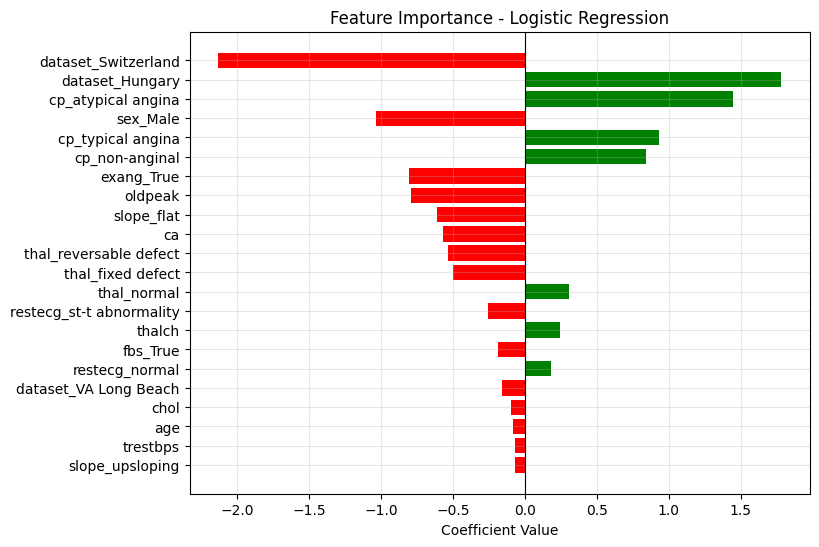

In [ ]:
# Create a dataframe for easy viewing/sorting
feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by absolute value of coefficient
feat_importance['Abs_Coefficient'] = feat_importance['Coefficient'].abs()
feat_importance = feat_importance.sort_values(by='Abs_Coefficient', ascending=False)

print(feat_importance[['Feature', 'Coefficient']])

# Plot
plt.figure(figsize=(8, 6))
colors = ['green' if c > 0 else 'red' for c in feat_importance['Coefficient']]
plt.barh(feat_importance['Feature'], feat_importance['Coefficient'], color=colors)
plt.xlabel('Coefficient Value')
plt.title('Feature Importance - Logistic Regression')
plt.gca().invert_yaxis()  # most important on top
plt.axvline(x=0, color='black', linewidth=0.8)
plt.grid(alpha=0.3)
plt.show()

## Results and Final Insights

- The dataset was cleaned and prepared by handling missing values and preprocessing relevant features.
- EDA helped identify patterns and relationships between health factors and heart disease risk.
- A classification model was successfully trained to predict the presence of heart disease.
- Model performance was evaluated using accuracy, ROC-AUC score, confusion matrix, and ROC curve analysis.
- Important features such as age, chest pain type, cholesterol level, maximum heart rate, and exercise-induced angina showed significant influence on predictions.
- The results demonstrated that machine learning can effectively assist in identifying individuals at risk of heart disease, supporting data-driven healthcare decision-making and early diagnosis.